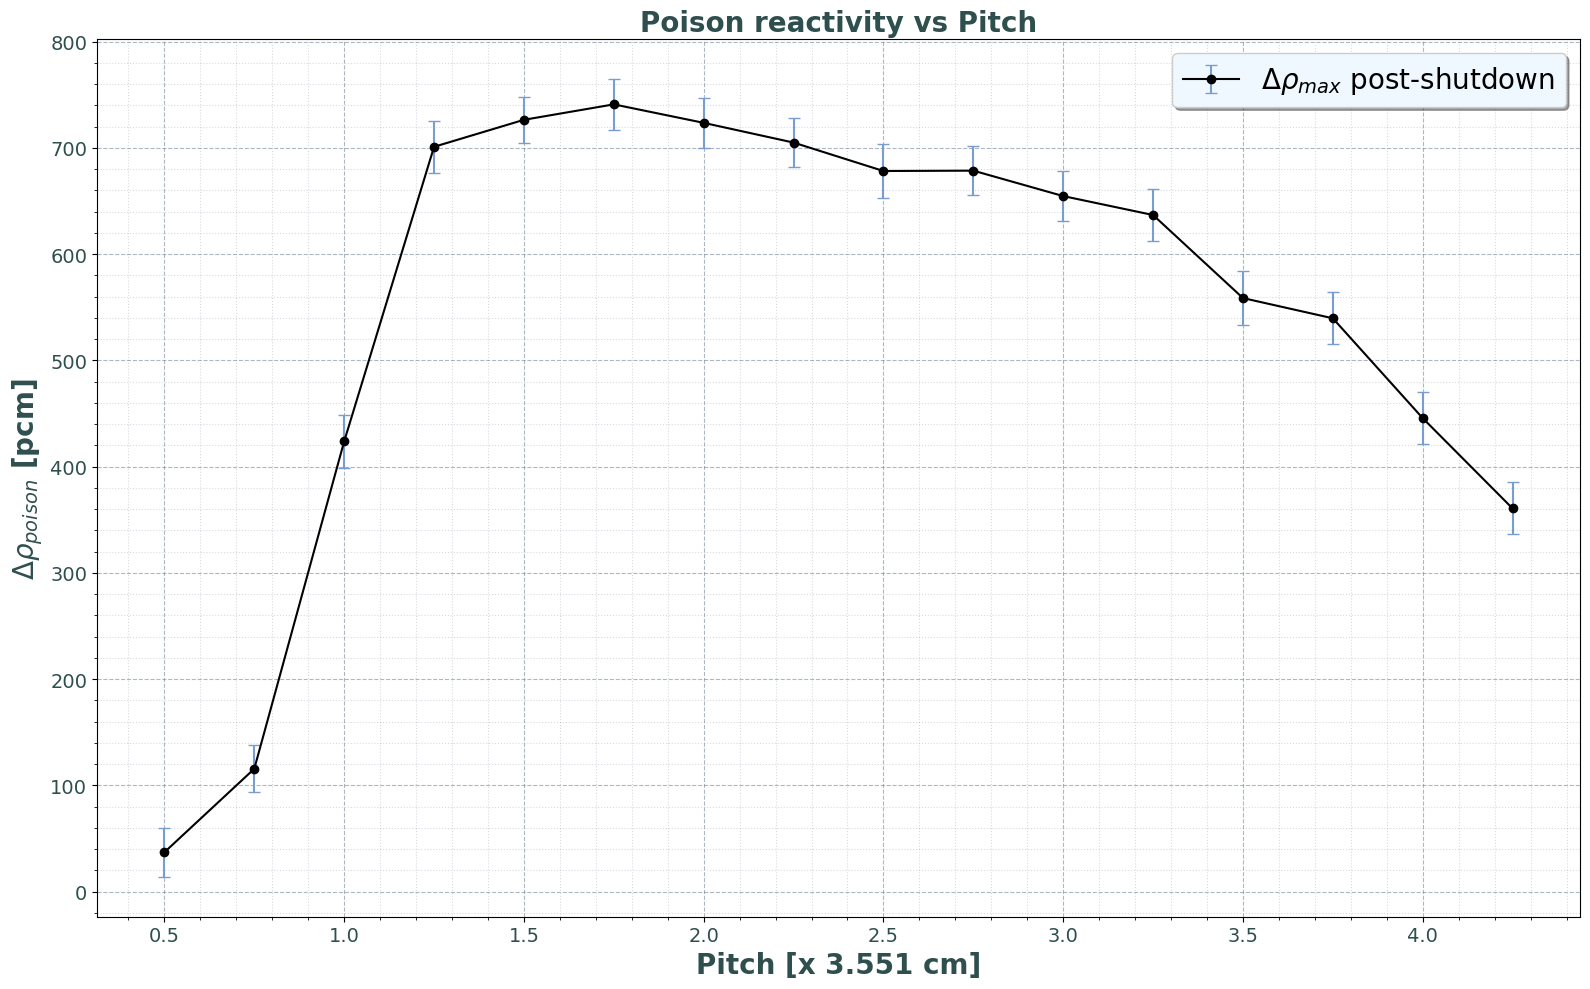

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# File di input
filename = "riepilogo_reattivita.txt"

pitches = []
delta_rho = []
err_delta_rho = []

# Lettura e parsing dei dati
with open(filename, 'r') as f:
    next(f)  # Salta l'intestazione
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 8:
            # Converte il pitch (es. "1_000") in float (1.000)
            pitch_val = float(parts[0].replace('_', '.'))
            d_rho = float(parts[6])
            err_d_rho = float(parts[7])
            
            pitches.append(pitch_val)
            delta_rho.append(d_rho)
            err_delta_rho.append(err_d_rho)

# Conversione in array numpy
pitches = np.array(pitches)
delta_rho = np.array(delta_rho)
err_delta_rho = np.array(err_delta_rho)

# Generazione del plot
fig, ax = plt.subplots(figsize=(16, 10))

# Plot dei dati con errori
ax.errorbar(pitches, delta_rho, yerr=err_delta_rho, fmt='o-', 
            color='#000000', ecolor='#789DD1', capsize=4, elinewidth=1.5, 
            label='$\Delta\\rho_{max}$ post-shutdown')

# Formattazione assi e titolo
ax.set_title("Poison reactivity vs Pitch", fontsize=20, fontweight='bold', color='#2F4F4F')
ax.set_xlabel("Pitch [x 3.551 cm]", fontsize=20, fontweight='bold', color='#2F4F4F')
ax.set_ylabel(r"$\Delta\rho_{poison}$ [pcm]", fontsize=20, fontweight='bold', color='#2F4F4F')
# Formattazione Tick (Major: 14, Minor: 12)
ax.minorticks_on()
ax.tick_params(axis='both', which='major', labelsize=14, labelcolor='#2F4F4F')
ax.tick_params(axis='both', which='minor', labelsize=12)
# Impostazioni griglia avanzata
ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')
# Legenda (Stile richiesto abilitato di default, loc='best', fontsize=16)
ax.legend(loc='best', frameon=True, shadow=True, fontsize=20, facecolor='#F0F8FF')
plt.tight_layout()
plt.savefig("poison_VS_pitch.png", dpi=300) # Salva il grafico ad alta risoluzione
plt.show()


Pitch      | Delta Rho Tot [pcm]       | k_max^HFP                
------------------------------------------------------------------------
0.500      | 6118.42    +/- 60.34      | 0.942343   +/- 0.000603  
0.750      | 3679.21    +/- 36.58      | 0.964514   +/- 0.000366  
1.000      | 2938.24    +/- 32.81      | 0.971456   +/- 0.000328  
1.250      | 2726.39    +/- 30.07      | 0.973460   +/- 0.000301  
1.500      | 2460.50    +/- 27.89      | 0.975986   +/- 0.000279  
1.750      | 2293.04    +/- 29.04      | 0.977584   +/- 0.000290  
2.000      | 2234.74    +/- 29.09      | 0.978141   +/- 0.000291  
2.250      | 2098.97    +/- 29.59      | 0.979442   +/- 0.000296  
2.500      | 2050.01    +/- 30.91      | 0.979912   +/- 0.000309  
2.750      | 1999.25    +/- 31.68      | 0.980399   +/- 0.000317  
3.000      | 1964.22    +/- 34.73      | 0.980736   +/- 0.000347  
3.250      | 1884.49    +/- 38.46      | 0.981504   +/- 0.000385  
3.500      | 1788.22    +/- 41.90      | 0.982432   +/-

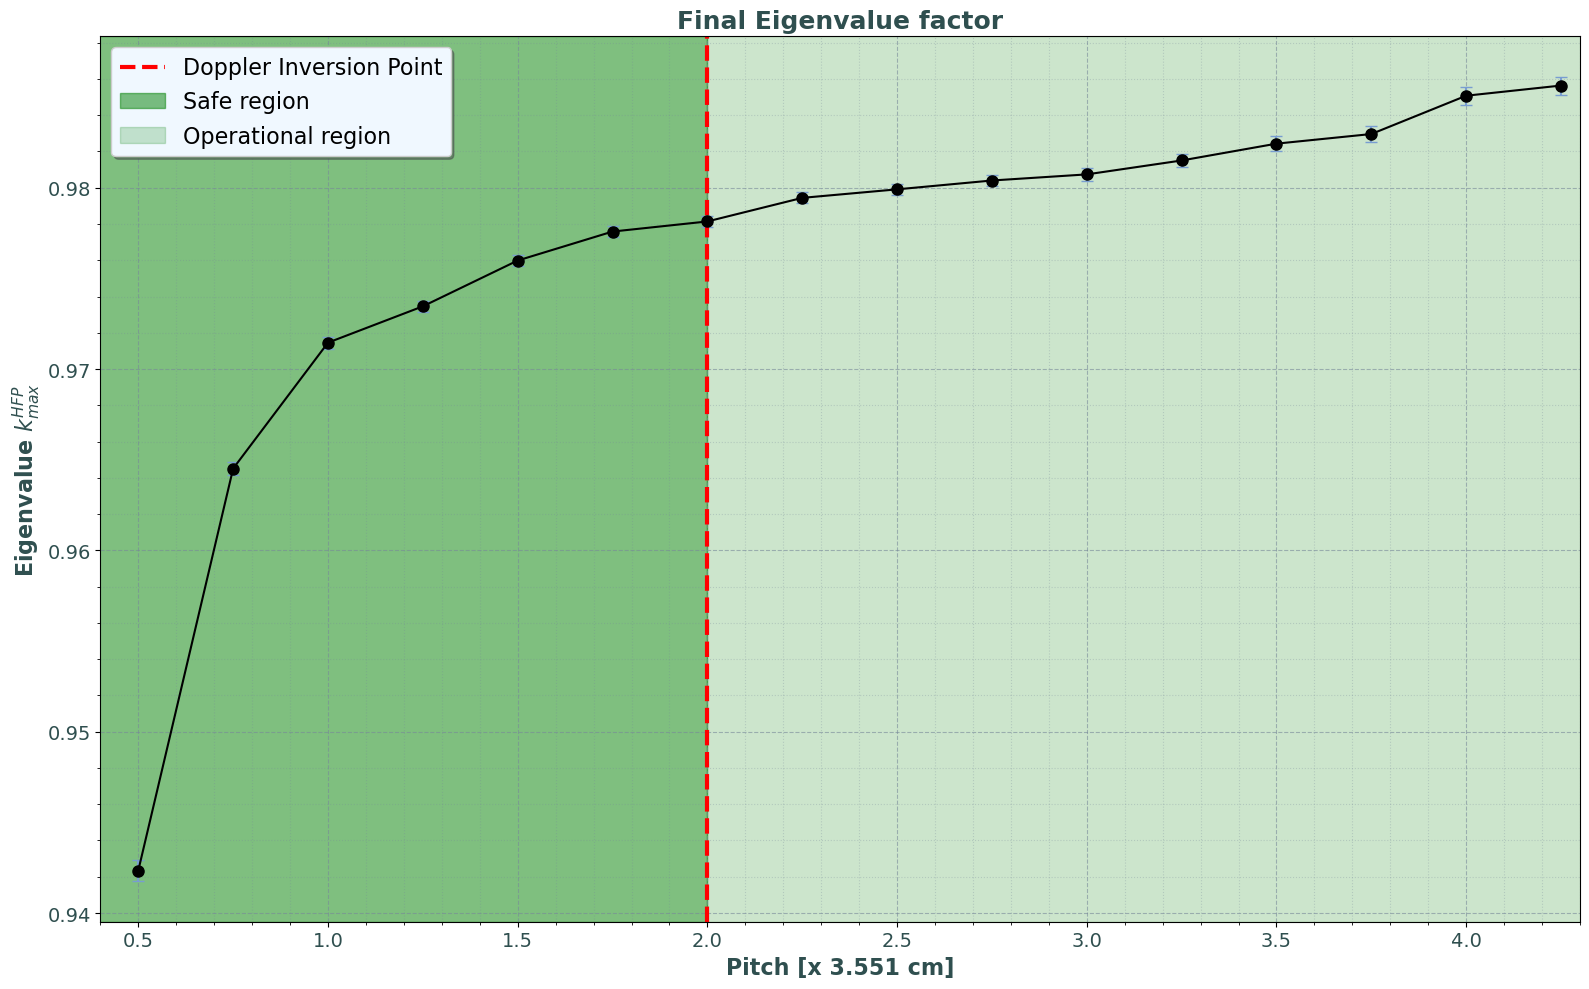

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Nomi dei file di input
file_shut = "riepilogo_reattivita.txt"
file_temp = "rho_temp.txt"

dict_shut = {}
# Lettura dati spegnimento post-shutdown
if os.path.exists(file_shut):
    with open(file_shut, 'r') as f:
        next(f)
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 8:
                pitch_val = float(parts[0].replace('_', '.'))
                delta_rho_shut = float(parts[6])
                err_rho_shut = float(parts[7])
                dict_shut[pitch_val] = (delta_rho_shut, err_rho_shut)
else:
    print(f"Errore: File {file_shut} non trovato.")

dict_temp_pow = {}
# Lettura dati temperatura e potenza
if os.path.exists(file_temp):
    with open(file_temp, 'r') as f:
        next(f)
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                pitch_val = float(parts[0])
                rho_temp = float(parts[1])
                err_temp = float(parts[2])
                rho_pow = float(parts[3])
                err_pow = float(parts[4])
                dict_temp_pow[pitch_val] = (rho_temp, err_temp, rho_pow, err_pow)
else:
    print(f"Errore: File {file_temp} non trovato.")

pitches = []
rho_tot_vals = []
err_rho_vals = []
k_vals = []
err_k_vals = []

# Intersezione e bilancio di reattività
for p in sorted(dict_shut.keys()):
    if p in dict_temp_pow:
        rho_shut, err_shut = dict_shut[p]
        rho_temp, err_temp, rho_pow, err_pow = dict_temp_pow[p]
        
        # Somma algebrica in pcm con aggiunta del margine di sicurezza
        rho_tot_pcm = 200 + rho_shut - rho_temp - rho_pow 
        
        # Propagazione quadratica degli errori su rho_tot
        err_rho_tot = np.sqrt(err_shut**2 + err_temp**2 + err_pow**2)
        
        # Conversione da rho (pcm) a k utilizzando k = 1 - (rho / 1e5)
        k = 1.0 /(1 + rho_tot_pcm / 1e5)
        err_k = err_rho_tot / 1e5
        
        pitches.append(p)
        rho_tot_vals.append(rho_tot_pcm)
        err_rho_vals.append(err_rho_tot)
        k_vals.append(k)
        err_k_vals.append(err_k)

pitches = np.array(pitches)
rho_tot_vals = np.array(rho_tot_vals)
err_rho_vals = np.array(err_rho_vals)
k_vals = np.array(k_vals)
err_k_vals = np.array(err_k_vals)

# --- STAMPA DELLA TABELLA A SCHERMO ---
print("\n" + "="*72)
print(f"{'Pitch':<10} | {'Delta Rho Tot [pcm]':<25} | {'k_max^HFP':<25}")
print("-" * 72)
for p, r, e_r, k, e_k in zip(pitches, rho_tot_vals, err_rho_vals, k_vals, err_k_vals):
    print(f"{p:<10.3f} | {r:<10.2f} +/- {e_r:<10.2f} | {k:<10.6f} +/- {e_k:<10.6f}")
print("="*72 + "\n")

# --- GENERAZIONE DEL PLOT ---
fig, ax = plt.subplots(figsize=(16, 10))

# Plot con i parametri di stile richiesti
ax.errorbar(pitches, k_vals, yerr=err_k_vals, fmt='o-', color='#000000', ecolor='#789DD1', 
            capsize=4, elinewidth=1.5, markersize=8)

# Formattazione assi e titolo

ax.set_title("Final Eigenvalue factor", fontsize=18, fontweight='bold', color='#2F4F4F')
ax.set_xlabel("Pitch [x 3.551 cm]", fontsize=16, fontweight='bold', color='#2F4F4F')
ax.set_ylabel("Eigenvalue $k_{max}^{HFP}$", fontsize=16, fontweight='bold', color='#2F4F4F')
ax.axvline(x=2.0, color='red', linestyle='--', linewidth=3, label='Doppler Inversion Point')

x_min_green = 0.3
x_max_green = 4.32

# --- Definizione delle Regioni ---
# Sfondo verde per l'intervallo specificato [0.375, 4.75]
ax.axvspan(x_min_green, 2, color='green', alpha=0.5, label='Safe region')
ax.axvspan(2, x_max_green, color='green', alpha=0.2, label='Operational region')


ax.set_xlim(0.4, 4.3)

# Formattazione Tick (Major: 14, Minor: 12)
ax.minorticks_on()
ax.tick_params(axis='both', which='major', labelsize=14, labelcolor='#2F4F4F')
ax.tick_params(axis='both', which='minor', labelsize=12)
# Impostazioni griglia avanzata
ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')
# Legenda (loc='best', fontsize=16)
ax.legend(loc='best', frameon=True, shadow=True, fontsize=16, facecolor='#F0F8FF')
plt.tight_layout()
plt.savefig("K_MASSIMO.png", dpi=300)
plt.show()